In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

from dask.diagnostics import ProgressBar

In [2]:
import sys
sys.path.append('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/')

In [3]:
import importlib
import StrucFunction
importlib.reload(StrucFunction)
from StrucFunction import *

In [4]:
def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

# 1.Eulerian part

In [43]:
file_path=f'/meddy/simingzhang/Data/SF_directly/'
fname='wv_SFaver.nc'
dsw=xr.open_dataset(file_path+fname)
fname='nwv_SFaver.nc'
dsnw=xr.open_dataset(file_path+fname)
fname='hit_SFaver.nc'
ds2d=xr.open_dataset(file_path+fname)
# ds2d=ds2d.isel(mid_rbins=slice(0,142))

In [111]:
dsw

<xarray.Dataset> Size: 7MB
Dimensions:    (time: 2148, mid_rbins: 48)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1970-01-01 ... 1970-01-01T00:35:47
    lev        int64 8B ...
  * mid_rbins  (mid_rbins) float64 384B 3e+03 5e+03 7e+03 ... 9.5e+04 9.7e+04
Data variables:
    dr         (time, mid_rbins) float64 825kB ...
    du3        (time, mid_rbins) float64 825kB ...
    dul2       (time, mid_rbins) float64 825kB ...
    dut2       (time, mid_rbins) float64 825kB ...
    theta      (time, mid_rbins) float64 825kB ...
    ulls       (time, mid_rbins) float64 825kB ...
    utts       (time, mid_rbins) float64 825kB ...
    du1        (time, mid_rbins) float64 825kB ...
    du2        (time, mid_rbins) float64 825kB ...
Attributes:
    chunk_index:  42
    grid:         m
    max_dist_m:   100000.0
    maxcorr:      120
    source:       run_chunked_structure_functions
    time_end:     2147
    time_start:   2100

# Lagrangian homogeneity

In [38]:
import scipy.io as sio

In [39]:
# flatten_mat_cell(pairs_sep['dul_rms'])*1e-5,flatten_mat_cell(pairs_sep['dul_m'])

In [40]:
A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/wave289roughsmall.mat')
# A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/wave289roughsmall_bin.mat')


pairs_sep=A['pairs_sep']
r1=np.squeeze(A['dist_axis'])
def flatten_mat_cell(x):
    return np.array([v.item() for v in x.flat])
dul_m_w = flatten_mat_cell(pairs_sep['dul_m'])
dul_s_w = flatten_mat_cell(pairs_sep['dul_s'])
dul_rms_w = flatten_mat_cell(pairs_sep['dul_rms'])
dul2_m_w = flatten_mat_cell(pairs_sep['dul2_m'])
dul2_s_w = flatten_mat_cell(pairs_sep['dul2_s'])
dul3_m_w = flatten_mat_cell(pairs_sep['dul3_m'])
dul3_s_w = flatten_mat_cell(pairs_sep['dul3_s'])
# ratio1_w = dul_m_w / (np.abs(dul_s_w)+np.abs(dul_rms_w))
ratio1_w = dul_m_w / (np.abs(dul_rms_w))
ratio2_w = dul2_m_w / dul2_s_w
ratio3_w = dul3_m_w / dul3_s_w

Ndul_w=A['Ndul']
vel_axis=np.squeeze(A['vel_axis'])

row_sums = np.sum(Ndul_w, axis=1, keepdims=True)
Ndul_norm_w = (Ndul_w / (row_sums + 1e-12))[1:-1, 1:-1].T
X = (r1[:-1])  
Y = vel_axis[:-1]    

# A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/wave1089rough.mat')
# pairs_sep=A['pairs_sep']
# r1=np.squeeze(A['dist_axis'])
# def flatten_mat_cell(x):
#     return np.array([v.item() for v in x.flat])
# dul_m_w = flatten_mat_cell(pairs_sep['dul_m'])
# dul_s_w = flatten_mat_cell(pairs_sep['dul_s'])
# dul_rms_w = flatten_mat_cell(pairs_sep['dul_rms'])

# dul2_m_w = flatten_mat_cell(pairs_sep['dul2_m'])
# dul2_s_w = flatten_mat_cell(pairs_sep['dul2_s'])
# dul3_m_w = flatten_mat_cell(pairs_sep['dul3_m'])
# dul3_s_w = flatten_mat_cell(pairs_sep['dul3_s'])
# # ratio1_w_e = dul_m_w / (np.abs(dul_s_w)+np.abs(dul_rms_w))
# ratio1_w_e = dul_m_w / (np.abs(dul_rms_w))
# ratio2_w_e = dul2_s_w / dul2_m_w
# ratio3_w_e = dul3_m_w / dul3_s_w

In [41]:
# A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/nowave289roughsmall.mat')
# Ndul=A['Ndul']
# Ndul.shape
# vel_axis=np.squeeze(A['vel_axis'])
# vel_axis.shape


In [42]:
# row_sums = np.sum(Ndul, axis=1, keepdims=True)
# Ndul_norm = Ndul / (row_sums + 1e-12)

# # ========== 严格对齐 MATLAB 的矩阵维度 ==========
# # MATLAB: Ndul_norm(1:end-1, 1:end-1)'
# # 1. 去掉最后一行和最后一列
# temp = Ndul_norm[1:-1, 1:-1]
# # 2. 转置
# data = temp.T

# X = (r2[:-1])  
# Y = vel_axis[:-1]      


# # # ========== 绘图 ==========
# plt.figure(figsize=(4, 3))
# plt.contourf(X_hit, Y_hit, np.log10(Ndul_norm_hit),cmap='jet')
# # plt.plot(r1[:-1],(dul_m_nw)[:-1],color='k')
# # plt.plot(r1[:-1],(-dul_s_nw)[:-1],color='k')
# plt.grid(True)
# plt.xscale('log')

In [43]:
A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/nowave289roughsmall.mat')
pairs_sep=A['pairs_sep']
r1=np.squeeze(A['dist_axis'])
def flatten_mat_cell(x):
    return np.array([v.item() for v in x.flat])
dul_m_nw = flatten_mat_cell(pairs_sep['dul_m'])
dul_s_nw = flatten_mat_cell(pairs_sep['dul_s'])
dul_rms_nw = flatten_mat_cell(pairs_sep['dul_rms'])
dul2_m_nw = flatten_mat_cell(pairs_sep['dul2_m'])
dul2_s_nw = flatten_mat_cell(pairs_sep['dul2_s'])
dul3_m_nw = flatten_mat_cell(pairs_sep['dul3_m'])
dul3_s_nw = flatten_mat_cell(pairs_sep['dul3_s'])
# ratio1_nw = dul_m_nw / (np.abs(dul_s_nw)+np.abs(dul_rms_w))
ratio1_nw = dul_m_nw / (np.abs(dul_rms_nw))
ratio2_nw = dul2_s_nw / dul2_m_nw
ratio3_nw = dul3_s_nw / dul3_m_nw

Ndul_nw=A['Ndul']
vel_axis=np.squeeze(A['vel_axis'])

row_sums = np.sum(Ndul_nw, axis=1, keepdims=True)
Ndul_norm_nw = (Ndul_nw / (row_sums + 1e-12))[1:-1, 1:-1].T
X = (r1[:-1])  
Y = vel_axis[:-1]    

# A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/nowave1089rough.mat')
# pairs_sep=A['pairs_sep']
# r1=np.squeeze(A['dist_axis'])
# def flatten_mat_cell(x):
#     return np.array([v.item() for v in x.flat])
# dul_m_nw = flatten_mat_cell(pairs_sep['dul_m'])
# dul_s_nw = flatten_mat_cell(pairs_sep['dul_s'])
# dul_rms_nw = flatten_mat_cell(pairs_sep['dul_rms'])
# dul2_m_nw = flatten_mat_cell(pairs_sep['dul2_m'])
# dul2_s_nw = flatten_mat_cell(pairs_sep['dul2_s'])
# dul3_m_nw = flatten_mat_cell(pairs_sep['dul3_m'])
# dul3_s_nw = flatten_mat_cell(pairs_sep['dul3_s'])
# # ratio1_nw_e = dul_m_nw / (np.abs(dul_s_nw)+np.abs(dul_rms_nw))
# ratio1_nw_e = dul_m_nw / (np.abs(dul_rms_nw))
# ratio2_nw_e = dul2_s_nw / dul2_m_nw
# ratio3_nw_e = dul3_s_nw / dul3_m_nw

In [44]:
# A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/hitroughsmall.mat')
# pairs_sep=A['pairs_sep']
# r2=np.squeeze(A['dist_axis'])
# def flatten_mat_cell(x):
#     return np.array([v.item() for v in x.flat])
# dul_m_hit = flatten_mat_cell(pairs_sep['dul_m'])
# dul_s_hit = flatten_mat_cell(pairs_sep['dul_s'])
# dul_rms_hit = flatten_mat_cell(pairs_sep['dul_rms'])
# dul2_m_hit = flatten_mat_cell(pairs_sep['dul2_m'])
# dul2_s_hit = flatten_mat_cell(pairs_sep['dul2_s'])
# dul3_m_hit = flatten_mat_cell(pairs_sep['dul3_m'])
# dul3_s_hit = flatten_mat_cell(pairs_sep['dul3_s'])
# # ratio1_hit = dul_m_hit / (np.abs(dul_s_hit)+np.abs(dul_rms_hit))
# ratio1_hit = dul_m_hit / (np.abs(dul_rms_hit))
# ratio2_hit = dul2_s_hit / dul2_m_hit
# ratio3_hit = dul3_s_hit / dul3_m_hit


A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/hitroughsmall_shao.mat')
pairs_sep=A['pairs_sep']
r2=np.squeeze(A['dist_axis'])
def flatten_mat_cell(x):
    return np.array([v.item() for v in x.flat])
dul_m_hit = flatten_mat_cell(pairs_sep['dul_m'])
dul_s_hit = flatten_mat_cell(pairs_sep['dul_s'])
dul_rms_hit = flatten_mat_cell(pairs_sep['dul_rms'])
dul2_m_hit = flatten_mat_cell(pairs_sep['dul2_m'])
dul2_s_hit = flatten_mat_cell(pairs_sep['dul2_s'])
dul3_m_hit = flatten_mat_cell(pairs_sep['dul3_m'])
dul3_s_hit = flatten_mat_cell(pairs_sep['dul3_s'])
# ratio1_hit2 = dul_s_hit / (np.abs(dul_m_hit)+np.abs(dul_rms_hit))
ratio1_hit2 = dul_m_hit / (np.abs(dul_rms_hit))
ratio2_hit2 = dul2_s_hit / dul2_m_hit
ratio3_hit2 = dul3_s_hit / dul3_m_hit

Ndul_hit=A['Ndul']
vel_axis=np.squeeze(A['vel_axis'])

row_sums = np.sum(Ndul_hit, axis=1, keepdims=True)
Ndul_norm_hit = (Ndul_hit / (row_sums + 1e-12))[1:-1, 1:-1].T
X_hit = (r2[:-1])  
Y_hit = vel_axis[:-1]      

In [45]:
idx=-1
pdf_hit = Ndul_norm_hit[:, idx]
du_hit = Y_hit
pdf_w = Ndul_norm_w[:, idx]
pdf_nw = Ndul_norm_nw[:, idx]
du_1 = Y

# δu_L^3 * P(δu_L)
du3_pdf_hit = du_hit**3 * pdf_hit
du3_pdf_w = du_1**3 * pdf_w
du3_pdf_nw = du_1**3 * pdf_nw

In [46]:
# check

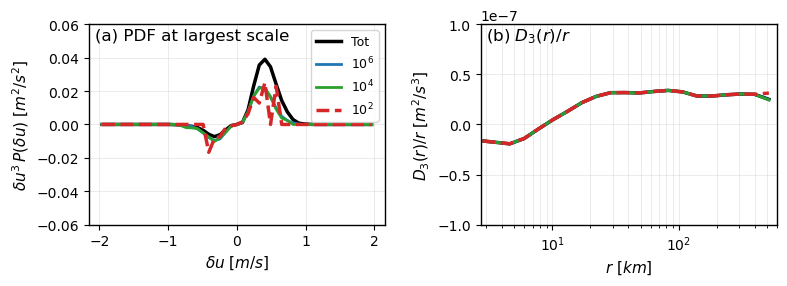

In [47]:
A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/nowave289roughsmall_bin.mat')
# A
Ndul_w1=np.squeeze(A['pdf'])
Ndul_w2=np.squeeze(A['pdf2'])
Ndul_w3=np.squeeze(A['pdf3'])
Ndul_w4=np.squeeze(A['pdf4'])
dul_3=(A['DUL_all'])


vel_axis=np.squeeze(A['vel_axis'])

du3_pdf_w1 = vel_axis**3 * Ndul_w1
du3_pdf_w2 = vel_axis**3 * Ndul_w2
du3_pdf_w3 = vel_axis**3 * Ndul_w3
du3_pdf_w4 = vel_axis**3 * Ndul_w4

# row_sums = np.sum(Ndul_w, axis=1, keepdims=True)
# Ndul_norm_w = (Ndul_w / (row_sums + 1e-12))[1:-1, 1:-1].T
# X = (r1[:-1])  
# Y = vel_axis[:-1]   
# ---------- Figure ----------
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=False)

# ---------- Left panel: PDF ----------
ax = axes[0]

ax.plot(vel_axis, du3_pdf_w1, lw=2.5, color='k', label='Tot')
ax.plot(vel_axis, du3_pdf_w2, lw=2,   color='C0', label=r'$10^{6}$')
ax.plot(vel_axis, du3_pdf_w3, lw=2,   color='C2', label=r'$10^{4}$')
ax.plot(vel_axis, du3_pdf_w4, lw=2.5, color='C3', ls='--', label=r'$10^{2}$')

ax.set_xlabel(r'$\delta u \ [m/s]$')
ax.set_ylabel(r'$\delta u^3 \, P(\delta u) \ [m^{2}/s^{2}]$')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.35, linewidth=0.5)
ax.set_ylim(-0.06, 0.06)

# ---------- Right panel: SF3 scaling ----------
ax = axes[1]

ax.semilogx(r1 * 1e-3, dul_3[:, 0]/r1, lw=2.5, color='k')
ax.semilogx(r1 * 1e-3, dul_3[:, 1]/r1, lw=2,   color='C0')
ax.semilogx(r1 * 1e-3, dul_3[:, 2]/r1, lw=2,   color='C2')
ax.semilogx(r1 * 1e-3, dul_3[:, 3]/r1, lw=2.5, color='C3', ls='--')

ax.set_xlim(2.7, 600)
ax.set_ylim(-1e-7, 1e-7)
ax.set_xlabel(r'$r \ [km]$')
ax.set_ylabel(r'$D_{3}(r)/r \ [m^{2}/s^{3}]$')
ax.grid(True, which='both', alpha=0.35, linewidth=0.5)

# ---------- Panel labels ----------
axes[0].text(0.02, 0.92, r'(a) PDF at largest scale',
             transform=axes[0].transAxes, fontsize=12)
axes[1].text(0.02, 0.92, r'(b) $D_{3}(r)/r$',
             transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.show()

In [48]:
dul_3.shape

(20, 4)

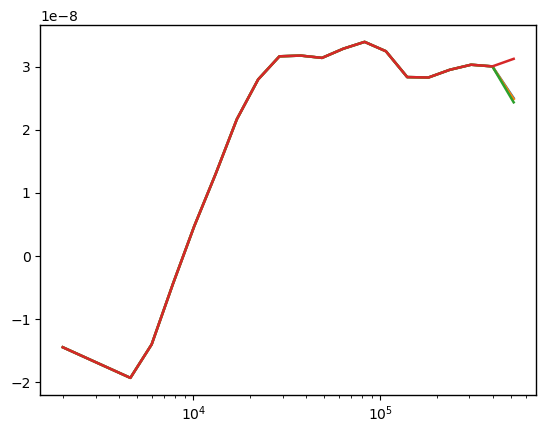

In [49]:
# plt.semilogx(r1,dul_3[:,5]/r1)
# # plt.semilogx(r1,dul_3[:,3]/r1)
# plt.semilogx(r1,dul_3[:,0]/r1)
for i in range(4):
    plt.semilogx(r1,dul_3[:,i]/r1)


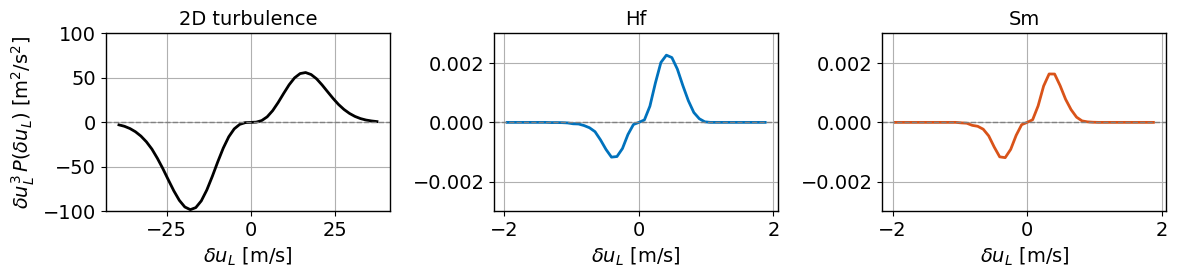

In [50]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# ==================== HIT ====================
ax = axes[0]
ax.plot(du_hit, du3_pdf_hit, 'k-', lw=2)
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_title('2D turbulence')
ax.set_xlabel(r'$\delta u_L\ [\mathrm{m/s}]$')
ax.set_ylabel(r'$\delta u_L^3\,P(\delta u_L)\ [\mathrm{m^2/s^2}]$')
ax.set_ylim(-100, 100)
ax.grid(True)

# ==================== HF ====================
ax = axes[1]
ax.plot(du_1, du3_pdf_w, '-', color='#0072BD', lw=2)
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_title('Hf')
ax.set_xlabel(r'$\delta u_L\ [\mathrm{m/s}]$')
ax.set_ylim(-0.003, 0.003)
ax.grid(True)

# ==================== SM ====================
ax = axes[2]
ax.plot(du_1, du3_pdf_nw, '-', color='#D95319', lw=2)
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_title('Sm')
ax.set_xlabel(r'$\delta u_L\ [\mathrm{m/s}]$')
ax.set_ylim(-0.003, 0.003)
ax.grid(True)

plt.tight_layout()
plt.savefig(
    '/meddy/simingzhang/Data/Figure_SF3/FigB_KHM_check.png',
    dpi=300,
    bbox_inches='tight'
)

In [51]:
A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/hitroughsmall_shao_linspace.mat')
pairs_sep=A['pairs_sep']
r2=np.squeeze(A['dist_axis'])
def flatten_mat_cell(x):
    return np.array([v.item() for v in x.flat])
dul_m_hit = flatten_mat_cell(pairs_sep['dul_m'])
dul_s_hit = flatten_mat_cell(pairs_sep['dul_s'])
dul_rms_hit = flatten_mat_cell(pairs_sep['dul_rms'])
dul2_m_hit = flatten_mat_cell(pairs_sep['dul2_m'])
dul2_s_hit = flatten_mat_cell(pairs_sep['dul2_s'])
dul3_m_hit = flatten_mat_cell(pairs_sep['dul3_m'])
dul3_s_hit = flatten_mat_cell(pairs_sep['dul3_s'])
# ratio1_hit2 = dul_s_hit / (np.abs(dul_m_hit)+np.abs(dul_rms_hit))
ratio1_hit2 = dul_m_hit / (np.abs(dul_rms_hit))
ratio2_hit2 = dul2_s_hit / dul2_m_hit
ratio3_hit2 = dul3_s_hit / dul3_m_hit

Ndul_hit=A['Ndul']
vel_axis=np.squeeze(A['vel_axis'])

row_sums = np.sum(Ndul_hit, axis=1, keepdims=True)
Ndul_norm_hit = (Ndul_hit / (row_sums + 1e-12))[1:-1, 1:-1].T
X_hit = (r2[:-1])  
Y_hit = vel_axis[:-1]     

idx=-1
pdf_hit = Ndul_norm_hit[:, idx]
du_hit = Y_hit
pdf_w = Ndul_norm_w[:, idx]
pdf_nw = Ndul_norm_nw[:, idx]
du_1 = Y

# δu_L^3 * P(δu_L)
du3_pdf_hit = du_hit**3 * pdf_hit
du3_pdf_w = du_1**3 * pdf_w
du3_pdf_nw = du_1**3 * pdf_nw

In [52]:
Ndul_norm_hit.shape

(48, 254)

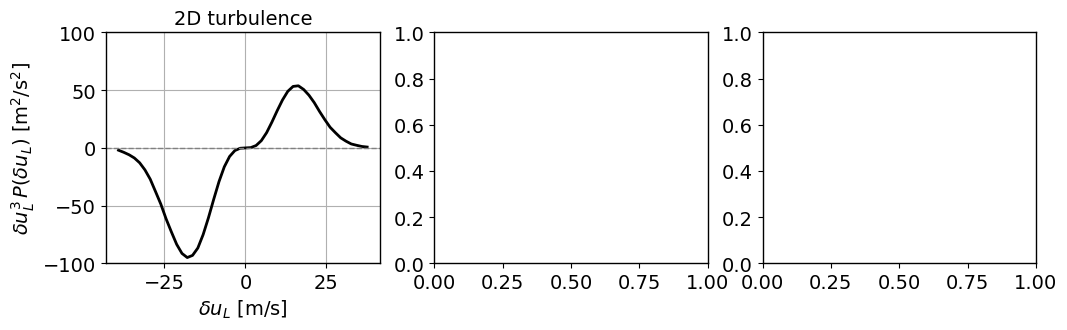

In [53]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# ==================== HIT ====================
ax = axes[0]
ax.plot(du_hit, du3_pdf_hit, 'k-', lw=2)
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_title('2D turbulence')
ax.set_xlabel(r'$\delta u_L\ [\mathrm{m/s}]$')
ax.set_ylabel(r'$\delta u_L^3\,P(\delta u_L)\ [\mathrm{m^2/s^2}]$')
ax.set_ylim(-100, 100)
ax.grid(True)


In [21]:
# fig1=plt.figure(figsize=(12,3))
# plt.subplot(1, 2, 1)
# plt.semilogx(r1,np.abs(ratio1_w),color='g')
# plt.semilogx(r1,np.abs(ratio2_w),color='r')
# plt.semilogx(r1,np.abs(ratio3_w),color='b')

# plt.semilogx(r1,np.abs(ratio1_nw),color='g',linestyle='--')
# plt.semilogx(r1,np.abs(ratio2_nw),color='r',linestyle='--')
# plt.semilogx(r1,np.abs(ratio3_nw),color='b',linestyle='--')
# plt.ylim(0,1)

# plt.subplot(1, 2, 2)
# plt.semilogx(r2,np.abs(ratio1_hit),color='g',linestyle=':')
# plt.semilogx(r2,np.abs(ratio2_hit),color='r',linestyle=':')
# plt.semilogx(r2,np.abs(ratio3_hit),color='b',linestyle=':')
# plt.ylim(0,1)


NameError: name 'ratio1_w_e' is not defined

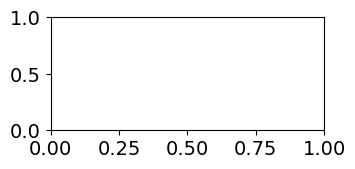

In [22]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
plt.figure(figsize=(12,5))
#------------------------------------------------HF---------------------------------------
plt.subplot(331)
plt.semilogx(r1*1e-3,np.abs(ratio1_w_e),label='Eul',linewidth=2)
plt.semilogx(r1*1e-3,np.abs(ratio1_w),label='Lag',linewidth=2)
# plt.loglog(rI_L*1e-3,iso1_L_hf,label='Lag')
# plt.ylim(0,0.2)
plt.xlim(3e0,1e2)
plt.legend(loc='best')
plt.title('Hf case')
plt.ylabel(r'$\frac{|std D_{1}|}{|mean D_{1}|+|rms D_{1}|}$')
plt.grid(True)

plt.subplot(334)
plt.semilogx(r1*1e-3,np.abs(ratio2_w_e),label='Eul',linewidth=2)
plt.semilogx(r1*1e-3,np.abs(ratio2_w),label='Lag',linewidth=2)
# plt.loglog(rI_L*1e-3,iso1_L_hf,label='Lag')
# plt.ylim(0,0.8)
plt.xlim(3e0,1e2)
plt.ylabel(r'$\frac{|std D_{2}|}{|mean D_{2}|}$')
plt.grid(True)

plt.subplot(337)
plt.semilogx(r1*1e-3,np.abs(ratio3_w_e),label='Eul',linewidth=2)
plt.semilogx(r1*1e-3,np.abs(ratio3_w),label='Lag',linewidth=2)
# plt.loglog(rI_L*1e-3,iso1_L_hf,label='Lag')
# plt.ylim(0,0.2)
plt.xlim(3e0,1e2)
plt.ylabel(r'$\frac{|std D_{3}|}{|mean D_{3}|}$')
plt.xlabel(r'r [km]')
plt.grid(True)

# #------------------------------------------------SM---------------------------------------
plt.subplot(332)
plt.semilogx(r1*1e-3,np.abs(ratio1_nw_e),label='Eul',linewidth=2)
plt.semilogx(r1*1e-3,np.abs(ratio1_nw),label='Lag',linewidth=2)
# plt.loglog(rI_L*1e-3,iso1_L_hf,label='Lag')
# plt.ylim(0,0.2)
plt.xlim(3e0,1e2)
plt.title('Sm case')
plt.grid(True)

plt.subplot(335)
plt.semilogx(r1*1e-3,np.abs(ratio2_nw_e),label='Eul',linewidth=2)
plt.semilogx(r1*1e-3,np.abs(ratio2_nw),label='Lag',linewidth=2)
# plt.ylim(0,0.8)
plt.xlim(3e0,1e2)
plt.grid(True)

plt.subplot(338)
plt.semilogx(r1*1e-3,np.abs(ratio3_nw_e),label='Eul',linewidth=2)
plt.semilogx(r1*1e-3,np.abs(ratio3_nw),label='Lag',linewidth=2)
# plt.ylim(0,0.2)
plt.xlim(3e0,1e2)
plt.xlabel(r'r [km]')
plt.grid(True)

# #------------------------------------------------hit---------------------------------------
plt.subplot(333)
# plt.loglog(rh_e,iso1_e_hit,label='Eul')
plt.semilogx(r2,np.abs(ratio1_hit),label='Eul',linewidth=2)
plt.semilogx(r2,np.abs(ratio1_hit2),label='Lag',linewidth=2)
# plt.ylim(0,0.2)
plt.xlim(5e-2,2.9)
plt.title('2D turb case')
plt.grid(True)

plt.subplot(336)
# plt.loglog(rh_e,iso1_e_hit,label='Eul')
plt.semilogx(r2,np.abs(ratio2_hit),label='Eul',linewidth=2)
plt.semilogx(r2,np.abs(ratio2_hit2),label='Lag',linewidth=2)
# plt.ylim(0,0.8)
plt.xlim(5e-2,2.9)
plt.grid(True)

plt.subplot(339)
# plt.loglog(rh_e,iso1_e_hit,label='Eul')
plt.semilogx(r2,np.abs(ratio3_hit),label='Eul',linewidth=2)
plt.semilogx(r2,np.abs(ratio3_hit2),label='Lag',linewidth=2)

# plt.ylim(0,200)
plt.xlim(5e-2,2.9)
plt.xlabel(r'r')
plt.grid(True)

plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.95,
    bottom=0.08,
    wspace=0.28,
    hspace=0.35
)

In [ ]:
abs(ratio1_hit).min(),abs(ratio1_nw).min()

/tmp/ipykernel_1713633/3691087813.py:33: RuntimeWarning: divide by zero encountered in log10
  ax2.contourf(X_hit, Y_hit, np.log10(Ndul_norm_hit),cmap='inferno',vmin=-7,vmax=0)
/tmp/ipykernel_1713633/3691087813.py:50: RuntimeWarning: divide by zero encountered in log10
  ax2.contourf(X* 1e-3, Y, np.log10(Ndul_norm_w),cmap='inferno',vmin=-7,vmax=0)
/tmp/ipykernel_1713633/3691087813.py:67: RuntimeWarning: divide by zero encountered in log10
  im2 =ax2.contourf(X* 1e-3, Y, np.log10(Ndul_norm_nw),cmap='inferno',vmin=-7,vmax=0)


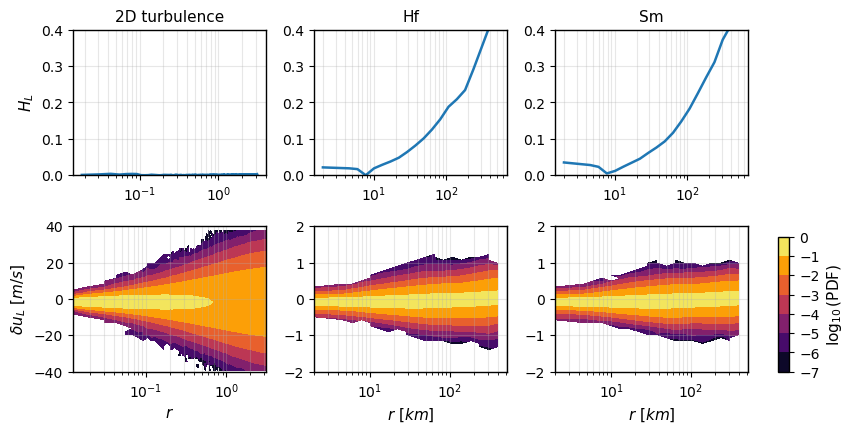

In [23]:
import matplotlib.pyplot as plt
import numpy as np

vmin = -7  # 对应你的要求
vmax = 0  # 对应你的要求
levels = np.linspace(vmin, vmax, 20)

# ========== 全局字体设置 ==========
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.8,
})

# 2 行 3 列布局
fig, axes = plt.subplots(2, 3, figsize=(7.5, 4.5))

# ==================== Column 0: 2D Turbulence (HIT) ====================
ax = axes[0, 0]
# ax.semilogx(r2, np.abs(ratio1_hit), 'C0-')
ax.semilogx(r2, np.abs(ratio1_hit2), 'C0-')
ax.set_ylim(0, 0.4)
ax.set_title('2D turbulence')
ax.set_ylabel(r'$H_{L}$')
ax.grid(True, which='both', alpha=0.3)

ax2 = axes[1, 0]
ax2.contourf(X_hit, Y_hit, np.log10(Ndul_norm_hit),cmap='inferno',vmin=-7,vmax=0)
ax2.set_xscale('log')
ax2.set_ylim(-40, 40)
ax2.grid(True, which='both', alpha=0.3)
ax2.set_xlabel(r'$r$')
ax2.set_ylabel(r'$\delta u_{L} \ [m/s]$')
ax2.set_xlim(r2.min(),r2.max())

# ==================== Column 1: HF Case ====================
ax = axes[0, 1]
# ax.semilogx(r1 * 1e-3, np.abs(ratio1_w_e), 'C0-', label='Eul')
ax.semilogx(r1 * 1e-3, np.abs(ratio1_w), 'C0-', label='Lag')
ax.set_ylim(0, 0.4)
ax.set_title('Hf')
ax.grid(True, which='both', alpha=0.3)

ax2 = axes[1, 1]
ax2.contourf(X* 1e-3, Y, np.log10(Ndul_norm_w),cmap='inferno',vmin=-7,vmax=0)
ax2.set_xscale('log')
ax2.set_ylim(-2, 2)
ax2.grid(True, which='both', alpha=0.3)
ax2.set_xlabel(r'$r \ [km]$')
ax2.set_xlim(r1.min()/1e3,r1.max()/1e3)


# ==================== Column 2: SM Case ====================
ax = axes[0, 2]
# ax.semilogx(r1 * 1e-3, np.abs(ratio1_nw_e), 'C0-')
ax.semilogx(r1 * 1e-3, np.abs(ratio1_nw), 'C0-')
ax.set_ylim(0, 0.4)
ax.set_title('Sm')
ax.grid(True, which='both', alpha=0.3)

ax2 = axes[1, 2]
im2 =ax2.contourf(X* 1e-3, Y, np.log10(Ndul_norm_nw),cmap='inferno',vmin=-7,vmax=0)
ax2.set_xscale('log')
ax2.set_ylim(-2, 2)
ax2.grid(True, which='both', alpha=0.3)
ax2.set_xlabel(r'$r \ [km]$')
ax2.set_xlim(r1.min()/1e3,r1.max()/1e3)

# ==================== 全局 Legend ====================
# handles, labels = axes[0, 1].get_legend_handles_labels() # 从 HF 列取 legend
# fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False,
#            bbox_to_anchor=(0.5, 1.05))
cbar_ax = fig.add_axes([1.02, 0.12, 0.015, 0.3]) # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label(r'$\log_{10}$(PDF)', fontsize=11)
# ==================== 精细调整间距 ====================
plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.88,
    bottom=0.12,
    wspace=0.25,
    hspace=0.35
)

plt.savefig('/meddy/simingzhang/Data/Figure_SF3/FigA_homogeneity.png', dpi=300, bbox_inches='tight')

In [ ]:
%   data source: Iceland (wave and no wave case)
%   utility: import parcels data to calc SF2,SF3
%   doesn't use bootstrap to resample,insteadly, calc time-mean SF2 and SF3 directly
%   code writer: zsm, modified from Balwada 2022 sciadv supplyment

%%%%%%%%%%%% test dist_bin code ########################
clear all;close all;clc
% addpath('D:\LIN2023\model\RoyBarkan\LLC4320/')
% addpath('D:\LIN2023\crocotools\Preprocessingtools') % add function "spheric_dist.m"
% 
addpath('/meddy/simingzhang/Analysis/matlab/Parcels_SF/')
addpath('/meddy/simingzhang/Data/Parcels_data')
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                          1. Basic setup and read data
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Case='wave'; % wave
nparticles=289; % numbers of particles
days=89.5;  % days
dt=3600; % s  Advection_RK4 delta_t drift时间间隔
% input_dir='D:\LIN2023\model\RoyBarkan\LLC4320/'; % drift所在文件夹
% ini='_roughbox200g_500m'
ini='_roughsmall'
timerange=1:1940;
% timerange=1:720;
% timerange=1220:1940;
%%% useless
if strcmpi(ini, '_grid')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_spectukey/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2km whole grid
if strcmpi(ini, '_rough') || strcmpi(ini, '_rough_1mon') || strcmpi(ini, '_rough_2mon')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2km 70*70box~140km
if strcmpi(ini, '_roughsmall') || strcmpi(ini, '_roughsmall_1mon') || strcmpi(ini, '_roughsmall_2mon') || strcmpi(ini, '_roughsmall_3mon')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2km LASER but in smallregion
if strcmpi(ini, '_roughLASER')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughLASER/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2month 140km box but in smallregion
% if strcmpi(ini, '_2month_roughsmall')
%     input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_2month_roughsmall/';
%     xscale=[2:18,21:3:48,54:6:114];
% end

%%% 2km 70*70box~140km rot
if strcmpi(ini, '_roughsmall_rot')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_rot/';
    xscale=[2:18,21:3:48,54:6:114];
end

if strcmpi(ini, '_roughsmall_div')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_div/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2km 70*70box~140km
if strcmpi(ini, '_cruise')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_cruise_roughsmallregion/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 500 m 280*280box~140km
if strcmpi(ini, '_roughsmall_500m') 
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/';
    xscale=[2:18,21:3:48,54:6:114,120:12:228,240:24:336];
end
%%% 500 m whole grid
if strcmpi(ini, '_rough_500m')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_rough_500m/';
    xscale=[2:18,21:3:48,54:6:114,120:12:228,240:24:336];
end
%%% 500 m 200*200box~100km
if strcmpi(ini, '_roughbox200g_500m')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughbox200g_500m/';
    xscale=[2:18,21:3:48,54:6:114,120:12:228,240:24:336];
end
%%% 500 m 100*100box~50km
if strcmpi(ini, '_roughbox100g_500m')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughbox100g_500m/';
    xscale=[2:18,21:3:48,54:6:114,120:12:228,240:24:336];
end
% input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_spectukey/';
% timerange=24*10:24*11-6; % 计算结构函数用的时间范围
% timerange=1:2140;
% timerange=1:960;
% timerange=1:1200;
% timerange=1:720;
% timerange=1:1428;
% timerange=1:720;


if strcmpi(Case, 'wave')
    fname=[input_dir,'wave_pars_P',num2str(nparticles),'T',num2str(days),'days.nc'];
end

if strcmpi(Case, 'nowave')
    fname=[input_dir,'nowave_pars_P',num2str(nparticles),'T',num2str(days),'days.nc'];
end

lon=ncread(fname,'lon');
lat=ncread(fname,'lat');

% ue=ncread(fname,'ue').*1852.*60.*cos(lat.*pi./180);
% ve=ncread(fname,'ve').*1852.*60;

ue=ncread(fname,'ue');
ve=ncread(fname,'ve');

lon=lon(timerange,:);
lat=lat(timerange,:);
ue=ue(timerange,:);
ve=ve(timerange,:);

% xscale=[2:18,21:3:48,54:6:114];
PI=zeros(1,length(xscale));
for iii=1:length(xscale)
    pistr=['th',num2str(xscale(iii))];
    eval(['th',num2str(xscale(iii)),'=ncread(fname,','''',pistr,'''',');'])
    % eval(['Th(',num2str(iii),')=nanmean(','th',num2str(xscale(iii)),'(:));'])
    eval(['Th_all(',num2str(iii),',:)=nanmean(','th', ...
        num2str(xscale(iii)),'(timerange,:),2);'])
end
%%%%%%%%%%%%%%%%check right?%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
% save([oname(1:end-3),'traj.mat'],'lons','lats','ues','ves','Th_all')

% read coarse-graining
% xscale=[2,4,6,8,10,12,16,20,30,50,60,100];
% PI=zeros(1,length(xscale));
% for iii=1:length(xscale)
%     pistr=['pi',num2str(xscale(iii))];
%     eval(['pi',num2str(xscale(iii)),'=ncread(fname,','''',pistr,'''',');'])
%     eval(['PI(',num2str(iii),')=nanmean(','pi',num2str(xscale(iii)),'(:));'])
% end
% semilogx(xscale,PI)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%              2. Calc Lagrangian Velocity and save *traj.mat
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


for t=1:size(lon,1)-1
    U(t,:)=(spheric_dist(lat(t,:),lat(t,:),lon(t,:),lon(t+1,:)))./dt.*...
        sign(lon(t+1,:)-lon(t,:));
    V(t,:)=(spheric_dist(lat(t+1,:),lat(t,:),lon(t,:),lon(t,:)))./dt.*...
        sign(lat(t+1,:)-lat(t,:));
end
lon(end,:)=[];lat(end,:)=[];

lon=lon;
lat=lat;
u=U;
v=V;
%%%%%%%%%%%%%%%%%%%%%there is a 2D experiment, So I assuming H=-501
%%%%%%%%%%%%%%%%%%%%%H 没有意义, 只是在Balwada的code里面只采样了500米以上的粒子

traj=struct();
traj.trajmat_X=lon;traj.trajmat_Y=lat;
traj.trajmat_U=u;traj.trajmat_V=v;
traj.H=-520.*ones(size(v,1),size(v,2));
traj.T_axis=linspace(dt, (size(v,1))*dt, size(v,1))./86400;

save([fname(1:end-3),ini,'traj.mat'],'traj');

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                 3. Calc pairs of particles' variables 
%                    pair_time 储存不同粒子对的变量
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
% follow Balwada's routine : "trajectories2binnedpairs_vectorized.m"

Htraj=traj.H;
%% Break up by time and separation bins
% took 58.9s for GLAD
% took 146s for LASER 
tic 
for i=1:length(traj.T_axis)
    disp(i)
    %id = find(~isnan(traj.trajmat_X(i,:))); % find non-NaN
    
    %id = find(~isnan(traj.trajmat_X(i,:)) & Htraj(i,:)<-500); % find non-Nan and deep
    % id = find(~isnan(traj.trajmat_X(i,:)) & Htraj(i,:)<-500 & ...
    %     traj.trajmat_X(i,:)>=-91 & traj.trajmat_X(i,:)<=-84 & ...
    %     traj.trajmat_Y(i,:)>=24); % find non-Nan and deep and in similar region to GLAD
    id = find(Htraj(i,:)<-500);
    % if mod(i,300)==0
    %     disp(i)
    % end
    
    if length(id)>1
        X = traj.trajmat_X(i,id)';
        Y = traj.trajmat_Y(i,id)';
        U = traj.trajmat_U(i,id)';
        V = traj.trajmat_V(i,id)';
        
        Xvec = [X, Y];
        
        pairs_time(i).dist = pdist(Xvec, @dist_geo);
        
        rx = pdist(Xvec, @dist_rx);
        ry = pdist(Xvec, @dist_ry);
        
        magr = sqrt(rx.^2 + ry.^2);
        
        rx = rx./magr; ry = ry./magr;
        
        dux = pdist(U, @dist_du);
        duy = pdist(V, @dist_du);
        
        pairs_time(i).dul = dux.*rx + duy.*ry;
        pairs_time(i).dut = duy.*rx - dux.*ry;
    else
        pairs_time(i).dul = NaN;
        pairs_time(i).dut = NaN;
        pairs_time(i).dist = NaN;
    end
end
toc
%% clear
p1=pairs_time;
clear pairs_time;
pairs_time=clear_nan_in_pairs_time(p1);
clear p1
%% error
% Ttot = days*24*3600;
Ttot = length(timerange)*3600;
% Ttot = 720*3600;
% Ttot = 1220*3600;
tpts = length(pairs_time);
%
npairs = zeros(tpts,1);
for i = 1:tpts
    npairs(i) = length(find(~isnan(pairs_time(i).dul)));
end

%% Make into a single vector
%
dul = zeros(sum(npairs),1);
dut = zeros(sum(npairs),1);
dist = zeros(sum(npairs),1);

%
% estimate num of pairs

empty1 = 1;
for i = 1:tpts % time loop
    if npairs(i) == 0
        continue
    end
    
    if npairs(i) == 1
        dist(empty1) = pairs_time(i).dist;
        dul(empty1) = pairs_time(i).dul;
        dut(empty1) = pairs_time(i).dut;
        empty1 = empty1+1;
    end
    
    if npairs(i) >1
        dist(empty1: empty1+npairs(i)-1) = pairs_time(i).dist;
        dul(empty1: empty1+npairs(i)-1) = pairs_time(i).dul;
        dut(empty1: empty1+npairs(i)-1) = pairs_time(i).dut;
        empty1 = empty1+npairs(i);
    end
    
end

%%
clear pairs_time

if strcmpi(ini, '_roughsmall_500m') || strcmpi(ini, '_rough_500m') || strcmpi(ini, '_roughbox200g_500m') || strcmpi(ini, '_roughbox100g_500m')

    
    % gamma = 1.3;
    % dist_bin(1) = 1000; % in m
    gamma = 1.3;
    dist_bin(1) = 1000; % in m
    dist_bin = gamma.^[0:100]*dist_bin(1);
    id = find(dist_bin>600*10^3,1);
    dist_bin = dist_bin(1:id-1);
    dist_bin(2:end+1) = dist_bin(1:end);
    dist_bin(1) = 0;
    dist_axis = 0.5*(dist_bin(1:end-1) + dist_bin(2:end));
    
    
    % Generate vel axis
    vel_bins = linspace(-2, 2, 50);
    vel_axis = 0.5*(vel_bins(1:end-1) + vel_bins(2:end));
else
    gamma = 1.3;

    dist_bin(1) = 4000; % in m
    dist_bin = gamma.^[0:100]*dist_bin(1);
    id = find(dist_bin>600*10^3,1);
    dist_bin = dist_bin(1:id-1);
    dist_bin(2:end+1) = dist_bin(1:end);
    dist_bin(1) = 0;
    %dist_bin = 0:4e3:200e3;
    dist_axis = 0.5*(dist_bin(1:end-1) + dist_bin(2:end));
    
    
    % Generate vel axis
    vel_bins = linspace(-2, 2, 50);
    vel_axis = 0.5*(vel_bins(1:end-1) + vel_bins(2:end));
end

edges = {dist_bin vel_bins};
%
Ndul = hist3([dist, dul], 'Edges', edges);

%%
tic

pairs_sep = struct('dul', 'dut');

for i = 1:length(dist_axis)
    disp(i)
    id = find(dist>= dist_bin(i) & dist<dist_bin(i+1));
    
    % pairs_sep(i).dul = dul(id);
    % pairs_sep(i).dut = dut(id);
    pairs_sep(i).dul_m=nanmean(dul(id));
    pairs_sep(i).dut_m=nanmean(dut(id));

    pairs_sep(i).cross_m=nanmean(dut(id).*dul(id));  
    pairs_sep(i).dul2_m=nanmean(dul(id).^2);
    pairs_sep(i).dut2_m=nanmean(dut(id).^2);
    pairs_sep(i).dul3_m=nanmean(dul(id).^3);
    pairs_sep(i).dultt_m=nanmean(dul(id).*dut(id).^2);
  
    pairs_sep(i).dul_s=nanstd(dul(id));
    pairs_sep(i).dul_rms=rms(dul(id), 'omitnan');
    pairs_sep(i).dul3_s=nanstd(dul(id).^3);
    pairs_sep(i).dul2_s=nanstd(dul(id).^2);
    pairs_sep(i).SF3_s=nanstd(dul(id).^3+dut(id).^2.*dul(id));
    pairs_sep(i).SF3_m=nanmean(dul(id).^3+dut(id).^2.*dul(id));
end
toc



save('wave289roughsmall_bin.mat','pairs_sep','dist_axis','vel_axis','Ndul')

In [20]:
N = 100
idx = np.random.choice(dul.shape[0], N, replace=False)
dul_sub = dul[idx]
# plt.plot(np.mean(dul**3))
# plt.plot(np.mean(dul_sub**3))
np.mean(dul**3),np.mean(dul_sub**3)

(0.020104657312490705, 0.023506506731825073)

In [ ]:
clear all;close all;clc
% addpath('D:\LIN2023\model\RoyBarkan\LLC4320/')
% addpath('D:\LIN2023\crocotools\Preprocessingtools') % add function "spheric_dist.m"
% 
addpath('/meddy/simingzhang/Analysis/matlab/Parcels_SF/')
addpath('/meddy/simingzhang/Data/Parcels_data')

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                          1. Basic setup and read data
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Case='HIT2d'; % wave
nparticles=62500; % numbers of particles
num_to_select = 7000;


days=89.5;  % days
seconds=20.0;  % days
dt=0.1; % s  Advection_RK4 delta_t drift时间间隔
timerange=50:150;
Ttot = 0.1*(timerange(end)-timerange(1));

% input_dir='D:\LIN2023\model\RoyBarkan\LLC4320/'; % drift所在文件夹
input_dir='/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/';
addpath(input_dir)
% timerange=24*10:24*11-6; % 计算结构函数用的时间范围
time_batch=1;
num_workers = 2; % 例如使用4个工作节点
% HIT2d_pars_P2500T0.2seconds.nc
fname=[input_dir,'wave_pars_P',num2str(nparticles),'T',num2str(days),'seconds.nc'];
if strcmpi(Case, 'wave')
    fname=[input_dir,'wave_pars_P',num2str(nparticles),'T',num2str(days),'seconds.nc'];
end

if strcmpi(Case, 'nowave')
    fname=[input_dir,'nowave_pars_P',num2str(nparticles),'T',num2str(days),'seconds.nc'];
end


if strcmpi(Case, 'HIT2d')
    fname=[input_dir,Case,'_pars_P',num2str(nparticles),'T',num2str(seconds),'.0seconds.nc'];
    oname=[input_dir,Case,'_pars_P',num2str(num_to_select),'T',num2str(seconds),'seconds.nc'];
end

lon=ncread(fname,'lon');
lat=ncread(fname,'lat');

ue=ncread(fname,'ue');
ve=ncread(fname,'ve');

num_columns = size(lon, 2); % 65536
random_indices = randperm(num_columns, num_to_select); % 随机选择不重复索引

% 抽取这些列
lons = lon(timerange, random_indices);
lats = lat(timerange, random_indices);
ues = ue(timerange, random_indices);
ves = ve(timerange, random_indices);




%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%              2. Calc Lagrangian Velocity and save *traj.mat
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


% for t=1:size(lon,1)-1
%     U(t,:)=(spheric_dist(lat(t,:),lat(t,:),lon(t,:),lon(t+1,:)))./dt.*...
%         sign(lon(t+1,:)-lon(t,:));
%     V(t,:)=(spheric_dist(lat(t+1,:),lat(t,:),lon(t,:),lon(t,:)))./dt.*...
%         sign(lat(t+1,:)-lat(t,:));
% end
% lon(end,:)=[];lat(end,:)=[];

lon=lons;
lat=lats;
ue=ues;
ve=ves;
%%%%%%%%%%%%%%%%%%%%%there is a 2D experiment, So I assuming H=-501
%%%%%%%%%%%%%%%%%%%%%H 没有意义, 只是在Balwada的code里面只采样了500米以上的粒子

traj=struct();
traj.trajmat_X=lon;traj.trajmat_Y=lat;
traj.trajmat_U=ue;traj.trajmat_V=ve;
traj.H=-520.*ones(size(ve,1),size(ve,2));
traj.T_axis=linspace(dt, (size(ve,1))*dt, size(ve,1))./86400;


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                 3. Calc pairs of particles' variables 
%                    pair_time 储存不同粒子对的变量
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

Htraj=traj.H;
%% Break up by time and separation bins
% took 58.9s for GLAD
% took 146s for LASER 
tic 
for i=1:length(traj.T_axis)
    disp(i)
    %id = find(~isnan(traj.trajmat_X(i,:))); % find non-NaN
    
    %id = find(~isnan(traj.trajmat_X(i,:)) & Htraj(i,:)<-500); % find non-Nan and deep
    % id = find(~isnan(traj.trajmat_X(i,:)) & Htraj(i,:)<-500 & ...
    %     traj.trajmat_X(i,:)>=-91 & traj.trajmat_X(i,:)<=-84 & ...
    %     traj.trajmat_Y(i,:)>=24); % find non-Nan and deep and in similar region to GLAD
    id = find(Htraj(i,:)<-500);
    % if mod(i,300)==0
    %     disp(i)
    % end
    
    if length(id)>1
        X = traj.trajmat_X(i,id)';
        Y = traj.trajmat_Y(i,id)';
        U = traj.trajmat_U(i,id)';
        V = traj.trajmat_V(i,id)';
        
        Xvec = [X, Y];
        
        pairs_time(i).dist = pdist(Xvec, @dist_nogeo);
        
        rx = pdist(Xvec, @dist_norx);
        ry = pdist(Xvec, @dist_nory);
        
        magr = sqrt(rx.^2 + ry.^2);
        
        rx = rx./magr; ry = ry./magr;
        
        dux = pdist(U, @dist_du);
        duy = pdist(V, @dist_du);
        
        pairs_time(i).dul = dux.*rx + duy.*ry;
        pairs_time(i).dut = duy.*rx - dux.*ry;
    else
        pairs_time(i).dul = NaN;
        pairs_time(i).dut = NaN;
        pairs_time(i).dist = NaN;
    end
end
toc
%% clear
p1=pairs_time;
clear pairs_time;
pairs_time=clear_nan_in_pairs_time(p1);
clear p1
%% error
% Ttot = days*24*3600;
Ttot = length(timerange)*3600;
% Ttot = 720*3600;
% Ttot = 1220*3600;
tpts = length(pairs_time);
%
npairs = zeros(tpts,1);
for i = 1:tpts
    npairs(i) = length(find(~isnan(pairs_time(i).dul)));
end

%% Make into a single vector
%
dul = zeros(sum(npairs),1);
dut = zeros(sum(npairs),1);
dist = zeros(sum(npairs),1);

%
% estimate num of pairs

empty1 = 1;
for i = 1:tpts % time loop
    if npairs(i) == 0
        continue
    end
    
    if npairs(i) == 1
        dist(empty1) = pairs_time(i).dist;
        dul(empty1) = pairs_time(i).dul;
        dut(empty1) = pairs_time(i).dut;
        empty1 = empty1+1;
    end
    
    if npairs(i) >1
        dist(empty1: empty1+npairs(i)-1) = pairs_time(i).dist;
        dul(empty1: empty1+npairs(i)-1) = pairs_time(i).dul;
        dut(empty1: empty1+npairs(i)-1) = pairs_time(i).dut;
        empty1 = empty1+npairs(i);
    end
    
end

%%
clear pairs_time

gamma = 1.2;
dist_bin(1) = 0.0123; % in m

dist_bin = gamma.^[0:100]*dist_bin(1);
%dist_bin = 0.0123 : 0.0123.*10 : 6.28;
%%% modifed by zsm
id = find(dist_bin>3.14*sqrt(2),1);
%id = find(dist_bin>6.14,1);

dist_bin = dist_bin(1:id-1);
dist_bin(2:end+1) = dist_bin(1:end);
% modified by zsm
dist_bin(1) = dist_bin(3)-dist_bin(2);
%dist_bin(1)=[];
dist_axis = 0.5*(dist_bin(1:end-1) + dist_bin(2:end));

nbins = 8;
theta_edges = linspace(-pi, pi, nbins+1);
theta_mid   = theta_edges(1:end-1) + diff(theta_edges)/2;


% Generate vel axis
vel_bins = linspace(-40, 40, 50);
vel_axis = 0.5*(vel_bins(1:end-1) + vel_bins(2:end));

edges = {dist_bin vel_bins};
%
Ndul = hist3([dist, dul], 'Edges', edges);

%%
tic

pairs_sep = struct('dul', 'dut');

for i = 1:length(dist_axis)
    disp(i)
    id = find(dist>= dist_bin(i) & dist<dist_bin(i+1));
    
%    pairs_sep(i).dul = dul(id);
%    pairs_sep(i).dut = dut(id);
    pairs_sep(i).dul_m=nanmean(dul(id));
    pairs_sep(i).dut_m=nanmean(dut(id));

    pairs_sep(i).cross_m=nanmean(dut(id).*dul(id));  
    pairs_sep(i).dul2_m=nanmean(dul(id).^2);
    pairs_sep(i).dut2_m=nanmean(dut(id).^2);
    pairs_sep(i).dul3_m=nanmean(dul(id).^3);
    pairs_sep(i).dultt_m=nanmean(dul(id).*dut(id).^2);
  
    pairs_sep(i).dul_s=nanstd(dul(id));
    pairs_sep(i).dul_rms=rms(dul(id), 'omitnan');
    pairs_sep(i).dul2_rms=rms(dul(id).^2, 'omitnan');
    pairs_sep(i).dul3_rms=rms(dul(id).^3, 'omitnan');
    pairs_sep(i).dul3_s=nanstd(dul(id).^3);
    pairs_sep(i).dul2_s=nanstd(dul(id).^2);

    pairs_sep(i).SF3_m=nanstd(dul(id).*(dul(id).^2+dut(id).^2));

end
toc
save('hitroughsmall_shao.mat','pairs_sep','dist_axis','vel_axis','Ndul')   
%save('hitroughsmall_shao_linspace.mat','pairs_sep','dist_axis','vel_axis','Ndul')   
%save('hitroughsmallSF1.mat','pairs_sep','dist_axis')   

# test std/mean

In [5]:
import scipy.io as sio

In [6]:
A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T1940_roughsmallbootstrapHL.mat')
# A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughbootstrapHL.mat')

r1=np.squeeze(A['dist_axis'])
SF1l_f_289=A['SF1l']
SF2l_f_289=A['SF2l']
SF3l_f_289=A['SF3l']
SF3_f_289=A['SF3']


SF1_m_f_hf_289=np.nanmean(SF1l_f_289,axis=1)
SF1_s_f_hf_289=np.nanstd(SF1l_f_289,axis=1)
SF1_rms_f_hf_289=np.sqrt(np.nanmean(SF1l_f_289**2,axis=1))

SF2_m_f_hf_289=np.nanmean(SF2l_f_289,axis=1)
SF2_s_f_hf_289=np.nanstd(SF2l_f_289,axis=1)
SF2_rms_f_hf_289=np.sqrt(np.nanmean(SF2l_f_289**2,axis=1))


SF3_m_f_hf_289=np.nanmean(SF3l_f_289,axis=1)
SF3_s_f_hf_289=np.nanstd(SF3l_f_289,axis=1)
SF3_rms_f_hf_289=np.sqrt(np.nanmean(SF3l_f_289**2,axis=1))

# sf3_m_f_hf_289=np.nanmean(SF3_f_hf_289,axis=1)
A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P289T1940_roughsmallbootstrapHL.mat')
r1=np.squeeze(A['dist_axis'])
SF1l_f_289=A['SF1l']
SF2l_f_289=A['SF2l']
SF3l_f_289=A['SF3l']
SF3_f_289=A['SF3']


SF1_m_f_sm_289=np.nanmean(SF1l_f_289,axis=1)
SF1_s_f_sm_289=np.nanstd(SF1l_f_289,axis=1)
SF1_rms_f_sm_289=np.sqrt(np.nanmean(SF1l_f_289**2,axis=1))

SF2_m_f_sm_289=np.nanmean(SF2l_f_289,axis=1)
SF2_s_f_sm_289=np.nanstd(SF2l_f_289,axis=1)
SF2_rms_f_sm_289=np.sqrt(np.nanmean(SF2l_f_289**2,axis=1))


SF3_m_f_sm_289=np.nanmean(SF3l_f_289,axis=1)
SF3_s_f_sm_289=np.nanstd(SF3l_f_289,axis=1)
SF3_rms_f_sm_289=np.sqrt(np.nanmean(SF3l_f_289**2,axis=1))

In [7]:
idx,idx2=2,32

A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/hitroughsmall_shao.mat')
pairs_sep=A['pairs_sep']
r2=np.squeeze(A['dist_axis'])[idx:idx2]
def flatten_mat_cell(x):
    return np.array([v.item() for v in x.flat])
dul_m_hit = flatten_mat_cell(pairs_sep['dul_m'])[idx:idx2]
dul_s_hit = flatten_mat_cell(pairs_sep['dul_s'])[idx:idx2]
dul_rms_hit = flatten_mat_cell(pairs_sep['dul_rms'])[idx:idx2]
dul2_m_hit = flatten_mat_cell(pairs_sep['dul2_m'])[idx:idx2]
dul2_s_hit = flatten_mat_cell(pairs_sep['dul2_s'])[idx:idx2]
dul2_rms_hit = flatten_mat_cell(pairs_sep['dul2_rms'])[idx:idx2]
dul3_m_hit = flatten_mat_cell(pairs_sep['dul3_m'])[idx:idx2]
dul3_s_hit = flatten_mat_cell(pairs_sep['dul3_s'])[idx:idx2]
dul3_rms_hit = flatten_mat_cell(pairs_sep['dul3_rms'])[idx:idx2]

# ratio1_hit2 = dul_s_hit / (np.abs(dul_m_hit)+np.abs(dul_rms_hit))
ratio1_hit2 = (dul_m_hit / (np.abs(dul_rms_hit)))
# ratio2_hit2 = (dul2_s_hit / dul2_m_hit)
ratio2_hit2 = (dul2_s_hit / dul2_m_hit)
ratio2_hit2 = ratio1_hit2**2
ratio3_hit2 = (dul3_m_hit / dul3_rms_hit)

A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T150timeavg6.mat')

from numpy.lib.stride_tricks import sliding_window_view

def smooth_axis1(data, window):
    # data shape: (25, 101)
    # 对 axis=1 做滑动平均
    windows = sliding_window_view(data, window, axis=1)  # (25, 92, 10)
    return windows.mean(axis=2)    


r2=np.squeeze(A['dist_axis'])[idx:idx2]
SF1l_f_289 = smooth_axis1(A['SF1l_time'][idx:idx2,:], window=31)
SF2l_f_289 = smooth_axis1(A['SF2ll_time'][idx:idx2,:],  window=31)
SF3l_f_289 = smooth_axis1(A['SF3lll_time'][idx:idx2,:],  window=31)

# SF1l_f_289=A['SF1l_time'][idx:idx2,:]
# SF2l_f_289=A['SF2ll_time'][idx:idx2,:]
# SF3l_f_289=A['SF3lll_time'][idx:idx2,:]

SF1_m_f_289=np.nanmean(SF1l_f_289,axis=1)
SF1_s_f_289=np.nanstd(SF1l_f_289,axis=1)
SF1_rms_f_289=np.sqrt(np.nanmean(SF1l_f_289**2,axis=1))

SF2_m_f_289=np.nanmean(SF2l_f_289,axis=1)
SF2_s_f_289=np.nanstd(SF2l_f_289,axis=1)

SF3_m_f_289=np.nanmean(SF3l_f_289,axis=1)
SF3_s_f_289=np.nanstd(SF3l_f_289,axis=1)
SF3_rms_f_289=np.sqrt(np.nanmean(SF3l_f_289**2,axis=1))


In [8]:
r2.shape,SF1_rms_f_289.shape,ratio1_hit2.shape,SF3_m_f_289.shape

((29,), (29,), (30,), (29,))

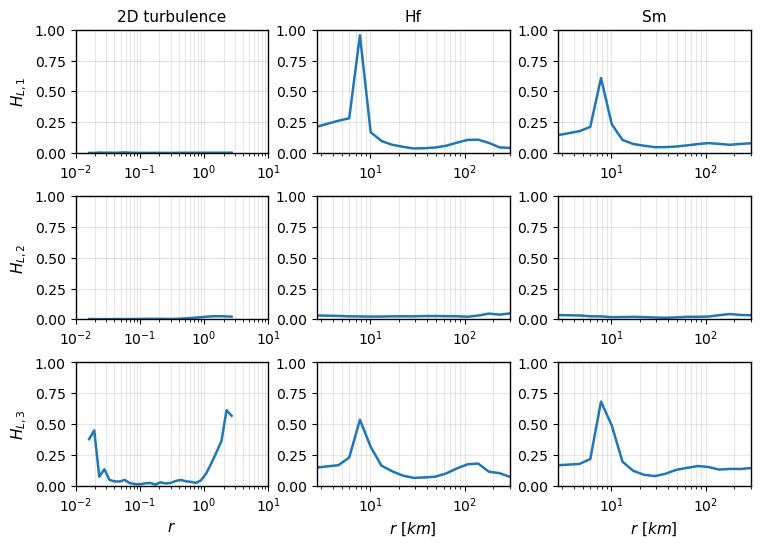

In [9]:
import matplotlib.pyplot as plt
import numpy as np

vmin = -7
vmax = 0
levels = np.linspace(vmin, vmax, 20)

# ========== 全局字体设置 ==========
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.8,
})

# ========== 3 行 3 列 ==========
fig, axes = plt.subplots(3, 3, figsize=(7.5, 6.0))

# ==================== Column 0: 2D Turbulence (HIT) ====================
ax = axes[0, 0]
ax.semilogx(r2, np.abs(ratio1_hit2)[1:], 'C0-')
# ax.semilogx(r2, SF1_s_f_289/(np.abs(SF1_m_f_289)+SF1_rms_f_289), 'C0-')
# ax.semilogx(r2, SF1_s_f_289/(np.abs(SF1_m_f_289)+SF1_rms_f_289), 'C0-')

ax.set_ylim(0, 1)
ax.set_title('2D turbulence')
ax.set_ylabel(r'$H_{L,1}$')
ax.grid(True, which='both', alpha=0.3)
# ax.set_xlim(0.0123, 6.28)
ax.set_xlim(1e-2, 1e1)


ax = axes[1, 0]
ax.semilogx(r2, SF2_s_f_289/SF2_m_f_289, 'C0-')
# ax.semilogx(r2, np.abs(ratio2_hit2), 'C0-',linewidth=4)
ax.set_ylim(0, 1)
ax.set_ylabel(r'$H_{L,2}$')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(1e-2, 1e1)

ax = axes[2, 0]
# ax.semilogx(r2, dul3_s_hit/(np.abs(dul3_m_hit)), 'C0-')
ax.semilogx(r2, SF3_s_f_289/(np.abs(SF3_m_f_289)+SF3_rms_f_289), 'C0-')
# ax.semilogx(r2, np.abs(ratio3_hit2), 'C0-')
ax.set_ylim(0, 1)
ax.set_ylabel(r'$H_{L,2}$')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$H_{L,3}$')
ax.set_xlim(1e-2, 1e1)

# ==================== Column 1: HF Case ====================
ax = axes[0, 1]
# ax.semilogx(r1 * 1e-3, SF1_s_f_hf_289/(np.abs(SF1_m_f_hf_289)+SF1_rms_f_hf_289.mean()), 'C0-')
ax.semilogx(r1 * 1e-3, SF1_s_f_hf_289/(np.abs(SF1_m_f_hf_289)+SF1_rms_f_hf_289), 'C0-')
ax.set_ylim(0, 1)
ax.set_title('Hf')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(2.7, 300)

ax = axes[1, 1]
ax.semilogx(r1 * 1e-3, SF2_s_f_hf_289/(np.abs(SF2_m_f_hf_289)), 'C0-')
ax.set_ylim(0, 1)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(2.7, 300)

ax = axes[2, 1]
# ax.semilogx(r1 * 1e-3, SF3_s_f_hf_289/(np.abs(SF3_m_f_hf_289)+SF3_rms_f_hf_289.mean()), 'C0-')
ax.semilogx(r1 * 1e-3, SF3_s_f_hf_289/(np.abs(SF3_m_f_hf_289)), 'C0-')

ax.set_ylim(0, 1)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlabel(r'$r \ [km]$')
ax.set_xlim(2.7, 300)

# ==================== Column 2: SM Case ====================
ax = axes[0, 2]
ax.semilogx(r1 * 1e-3, SF1_s_f_sm_289/(np.abs(SF1_m_f_sm_289)+SF1_rms_f_sm_289), 'C0-')
ax.set_ylim(0, 1)
ax.grid(True, which='both', alpha=0.3)
ax.set_title('Sm')
ax.set_xlim(2.7, 300)

ax = axes[1, 2]
ax.semilogx(r1 * 1e-3, SF2_s_f_sm_289/(np.abs(SF2_m_f_sm_289)), 'C0-')
ax.set_ylim(0, 1)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(2.7, 300)

ax = axes[2, 2]
ax.semilogx(r1 * 1e-3, SF3_s_f_sm_289/(np.abs(SF3_m_f_sm_289)), 'C0-')
ax.set_ylim(0, 1)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlabel(r'$r \ [km]$')
ax.set_xlim(2.7, 300)

# ==================== Colorbar ====================
# cbar_ax = fig.add_axes([1.02, 0.12, 0.015, 0.3])
# cbar = fig.colorbar(im2, cax=cbar_ax)
# cbar.set_label(r'$\log_{10}$(PDF)', fontsize=11)

# ==================== 精细调整间距 ====================
plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.88,
    bottom=0.12,
    wspace=0.25,
    hspace=0.35
)
plt.savefig('/meddy/simingzhang/Data/Figure_SF3/FigA_homogeneity2.png', dpi=300, bbox_inches='tight')
plt.show()

In [131]:
# plt.semilogx(r1*1e-3,SF1_m_f_hf_289,label='mean')
# plt.semilogx(r1*1e-3,SF1_s_f_hf_289,label='std')
# plt.semilogx(r1*1e-3,SF1_rms_f_hf_289,label='RMS')
# plt.grid(True)
# plt.legend()
SF1_rms_f_hf_289.mean()

0.031173410060574946

In [141]:
SF3_s_f_sm_289/(np.abs(SF3_m_f_sm_289))

array([0.15947071, 0.17694207, 0.21655692, 0.68259048, 0.48909767,
       0.19496893, 0.12097987, 0.08890245, 0.07789311, 0.09684355,
       0.12885522, 0.14474824, 0.15953428, 0.15184242, 0.13077606,
       0.13634789, 0.13578514, 0.14360651, 0.1757059 , 0.28231423])

In [142]:
SF1l_f_289.shape

(29, 97)

In [10]:
A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T150timeavg6.mat')
idx,idx2=0,-1

r2=np.squeeze(A['dist_axis'])[idx:idx2]

SF3_m_f_289=np.nanmean(SF3l_f_289,axis=1)
SF3_s_f_289=np.nanstd(SF3l_f_289,axis=1)

SF3_hit_1000=np.squeeze(A['SF3_mean'])[idx:idx2]
# # A
# SF1l_f_289.shape
# A

KeyError: 'SF1l_time'

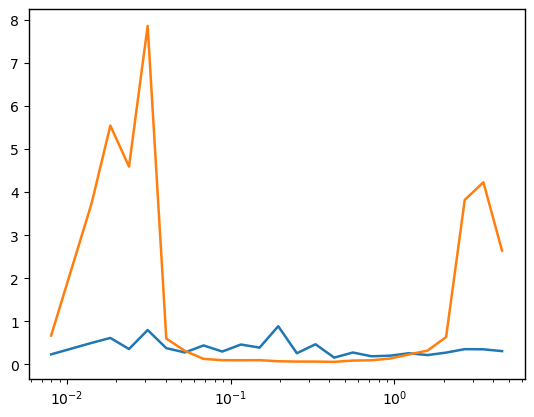

In [29]:
A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T150boxavg7.mat')
SF1l=A['SF1l']
SF3l=A['SF3l']
rr=np.squeeze(A['dist_axis'])
SF1l_m=np.nanmean(SF1l,axis=1)
SF1l_s=np.nanstd(SF1l,axis=1)
SF1l_rms=np.sqrt(np.nanmean(SF1l**2,axis=1))
SF3l_m=np.nanmean(SF3l,axis=1)
SF3l_s=np.nanstd(SF3l,axis=1)
SF3l_rms=np.sqrt(np.nanmean(SF3l**2,axis=1))
# plt.semilogx(rr,np.abs(SF1l_m))
# plt.semilogx(rr,SF1l_s)
# plt.semilogx(rr,SF1l_rms)
plt.semilogx(rr,SF1l_s/(np.abs(SF1l_m)+SF1l_rms))
plt.semilogx(rr,SF3l_s/(np.abs(SF3l_m)))


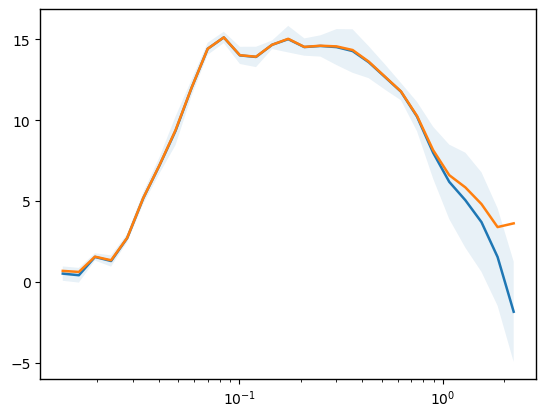

In [160]:
plt.semilogx(r2[1:],SF3_m_f_289/r2[1:])
# plt.semilogx(r2,SF3_hit_1000/r2)
plt.fill_between(r2[1:],(SF3_m_f_289+SF3_s_f_289)/r2[1:],(SF3_m_f_289-SF3_s_f_289)/r2[1:],alpha=0.1)
plt.semilogx(r2[1:],SF3_rms_f_289/r2[1:])


(0.0, 2.0)

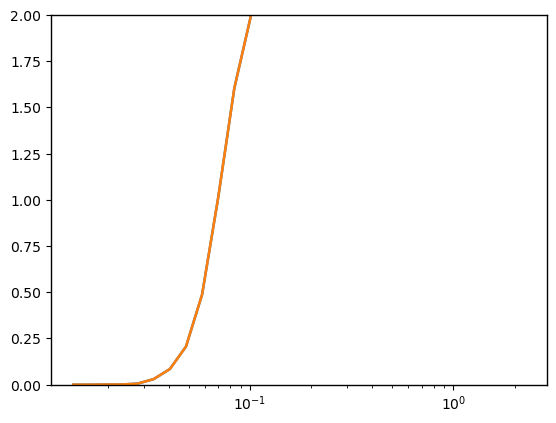

In [161]:
plt.semilogx(r2[1:],SF3_m_f_289**2+SF3_s_f_289**2)
plt.semilogx(r2[1:],SF3_rms_f_289**2)
plt.ylim(0,2)

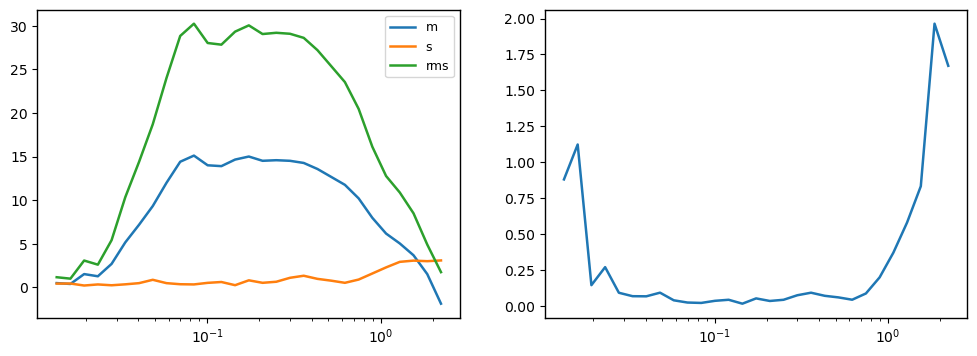

In [162]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.semilogx(r2[1:],SF3_m_f_289/r2[1:],label='m')
plt.semilogx(r2[1:],SF3_s_f_289/r2[1:],label='s')
plt.semilogx(r2[1:],(SF3_m_f_289+SF3_rms_f_289)/r2[1:],label='rms')
plt.legend()
# plt.fill_between(r2[1:],(SF3_m_f_289+SF3_s_f_289)/r2[1:],(SF3_m_f_289-SF3_s_f_289)/r2[1:],alpha=0.1)
# plt.semilogx(r2[1:],SF3_rms_f_289/r2[1:])
plt.subplot(122)
plt.semilogx(r2[1:],SF3_s_f_289/(np.abs(SF3_m_f_289)),label='m')



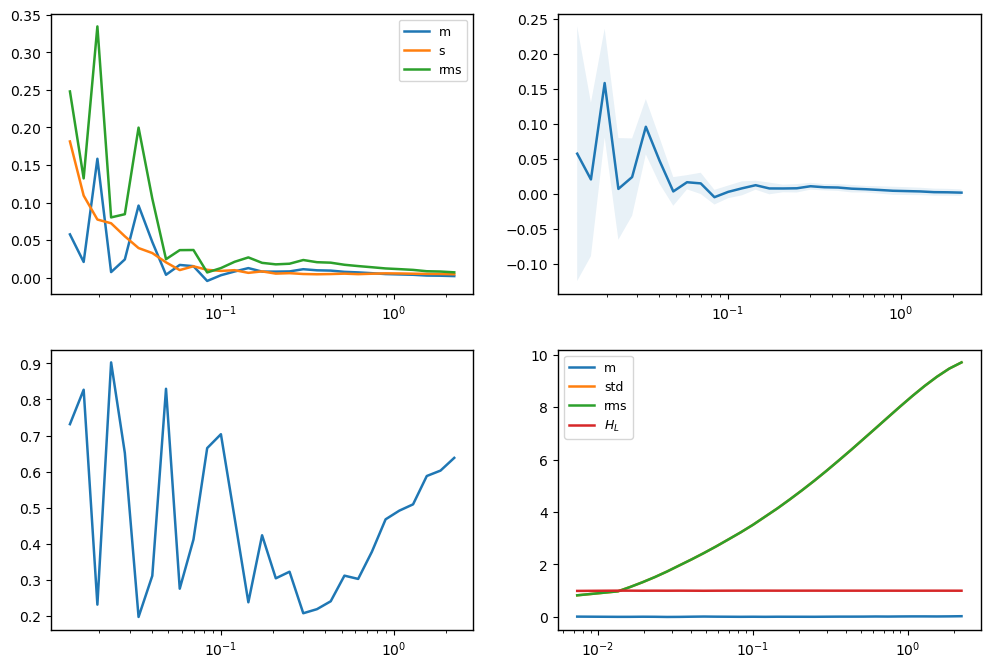

In [119]:
SF1_m_f_289=np.nanmean(SF1l_f_289,axis=1)
SF1_s_f_289=np.nanstd(SF1l_f_289,axis=1)
SF1_rms_f_289=np.sqrt(np.nanmean(SF1l_f_289**2,axis=1))

SF2_m_f_289=np.nanmean(SF2l_f_289,axis=1)
SF2_s_f_289=np.nanstd(SF2l_f_289,axis=1)

plt.figure(figsize=(12,8))
plt.subplot(221)
plt.semilogx(r2[1:],SF1_m_f_289/r2[1:],label='m')
plt.semilogx(r2[1:],SF1_s_f_289/r2[1:],label='s')
plt.semilogx(r2[1:],(SF1_m_f_289+SF1_rms_f_289)/r2[1:],label='rms')
plt.legend()
# plt.fill_between(r2[1:],(SF3_m_f_289+SF3_s_f_289)/r2[1:],(SF3_m_f_289-SF3_s_f_289)/r2[1:],alpha=0.1)
# plt.semilogx(r2[1:],SF3_rms_f_289/r2[1:])
plt.subplot(222)
plt.semilogx(r2[1:],SF1_m_f_289/r2[1:])
# plt.semilogx(r2,SF3_hit_1000/r2)
plt.fill_between(r2[1:],(SF1_m_f_289+SF1_s_f_289)/r2[1:],(SF1_m_f_289-SF1_s_f_289)/r2[1:],alpha=0.1)
# plt.semilogx(r2[1:],SF3_s_f_289/(np.abs(SF3_m_f_289)),label='m')

plt.subplot(223)
plt.semilogx(r2[1:],SF1_s_f_289/(np.abs(SF1_m_f_289)+SF1_rms_f_289))

plt.subplot(224)
plt.semilogx(r2,dul_m_hit,label='m')
plt.semilogx(r2,dul_s_hit,label='std')
plt.semilogx(r2,dul_rms_hit,label='rms')
plt.semilogx(r2,dul_s_hit/(np.abs(dul_m_hit)+dul_rms_hit),label=r'$H_{L}$')
plt.legend()
# plt.fill_between(r2,(dul_m_hit+dul_s_hit),(dul_m_hit-dul_s_hit),alpha=0.1)



In [ ]:
%   data source: Iceland (wave and no wave case)
%   utility: import parcels data to calc SF2,SF3
%   doesn't use bootstrap to resample,insteadly, calc time-mean SF2 and SF3 directly
%   code writer: zsm, modified from Balwada 2022 sciadv supplyment

%%%%%%%%%%%% test dist_bin code ########################
clear all;close all;clc
% addpath('D:\LIN2023\model\RoyBarkan\LLC4320/')
% addpath('D:\LIN2023\crocotools\Preprocessingtools') % add function "spheric_dist.m"
% 
addpath('/meddy/simingzhang/Analysis/matlab/Parcels_SF/')
addpath('/meddy/simingzhang/Data/Parcels_data')
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                          1. Basic setup and read data
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Case='nowave'; % wave
nparticles=289; % numbers of particles
days=89.5;  % days
dt=3600; % s  Advection_RK4 delta_t drift时间间隔
% input_dir='D:\LIN2023\model\RoyBarkan\LLC4320/'; % drift所在文件夹
% ini='_roughbox200g_500m'
ini='_roughsmall'
timerange=1:1940;
% timerange=1:720;
% timerange=1220:1940;
%%% useless
if strcmpi(ini, '_grid')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_spectukey/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2km whole grid
if strcmpi(ini, '_rough') || strcmpi(ini, '_rough_1mon') || strcmpi(ini, '_rough_2mon')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2km 70*70box~140km
if strcmpi(ini, '_roughsmall') || strcmpi(ini, '_roughsmall_1mon') || strcmpi(ini, '_roughsmall_2mon') || strcmpi(ini, '_roughsmall_3mon')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2km LASER but in smallregion
if strcmpi(ini, '_roughLASER')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughLASER/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2month 140km box but in smallregion
% if strcmpi(ini, '_2month_roughsmall')
%     input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_2month_roughsmall/';
%     xscale=[2:18,21:3:48,54:6:114];
% end

%%% 2km 70*70box~140km rot
if strcmpi(ini, '_roughsmall_rot')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_rot/';
    xscale=[2:18,21:3:48,54:6:114];
end

if strcmpi(ini, '_roughsmall_div')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_div/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 2km 70*70box~140km
if strcmpi(ini, '_cruise')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_cruise_roughsmallregion/';
    xscale=[2:18,21:3:48,54:6:114];
end
%%% 500 m 280*280box~140km
if strcmpi(ini, '_roughsmall_500m') 
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion_500m/';
    xscale=[2:18,21:3:48,54:6:114,120:12:228,240:24:336];
end
%%% 500 m whole grid
if strcmpi(ini, '_rough_500m')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_rough_500m/';
    xscale=[2:18,21:3:48,54:6:114,120:12:228,240:24:336];
end
%%% 500 m 200*200box~100km
if strcmpi(ini, '_roughbox200g_500m')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughbox200g_500m/';
    xscale=[2:18,21:3:48,54:6:114,120:12:228,240:24:336];
end
%%% 500 m 100*100box~50km
if strcmpi(ini, '_roughbox100g_500m')
    input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughbox100g_500m/';
    xscale=[2:18,21:3:48,54:6:114,120:12:228,240:24:336];
end
% input_dir='/meddy/simingzhang/Data/Parcels_data/tranV_onetime_spectukey/';
% timerange=24*10:24*11-6; % 计算结构函数用的时间范围
% timerange=1:2140;
% timerange=1:960;
% timerange=1:1200;
% timerange=1:720;
% timerange=1:1428;
% timerange=1:720;


if strcmpi(Case, 'wave')
    fname=[input_dir,'wave_pars_P',num2str(nparticles),'T',num2str(days),'days.nc'];
end

if strcmpi(Case, 'nowave')
    fname=[input_dir,'nowave_pars_P',num2str(nparticles),'T',num2str(days),'days.nc'];
end

lon=ncread(fname,'lon');
lat=ncread(fname,'lat');

% ue=ncread(fname,'ue').*1852.*60.*cos(lat.*pi./180);
% ve=ncread(fname,'ve').*1852.*60;

ue=ncread(fname,'ue');
ve=ncread(fname,'ve');

lon=lon(timerange,:);
lat=lat(timerange,:);
ue=ue(timerange,:);
ve=ve(timerange,:);

% xscale=[2:18,21:3:48,54:6:114];
PI=zeros(1,length(xscale));
for iii=1:length(xscale)
    pistr=['th',num2str(xscale(iii))];
    eval(['th',num2str(xscale(iii)),'=ncread(fname,','''',pistr,'''',');'])
    % eval(['Th(',num2str(iii),')=nanmean(','th',num2str(xscale(iii)),'(:));'])
    eval(['Th_all(',num2str(iii),',:)=nanmean(','th', ...
        num2str(xscale(iii)),'(timerange,:),2);'])
end
%%%%%%%%%%%%%%%%check right?%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
% save([oname(1:end-3),'traj.mat'],'lons','lats','ues','ves','Th_all')

% read coarse-graining
% xscale=[2,4,6,8,10,12,16,20,30,50,60,100];
% PI=zeros(1,length(xscale));
% for iii=1:length(xscale)
%     pistr=['pi',num2str(xscale(iii))];
%     eval(['pi',num2str(xscale(iii)),'=ncread(fname,','''',pistr,'''',');'])
%     eval(['PI(',num2str(iii),')=nanmean(','pi',num2str(xscale(iii)),'(:));'])
% end
% semilogx(xscale,PI)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%              2. Calc Lagrangian Velocity and save *traj.mat
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


for t=1:size(lon,1)-1
    U(t,:)=(spheric_dist(lat(t,:),lat(t,:),lon(t,:),lon(t+1,:)))./dt.*...
        sign(lon(t+1,:)-lon(t,:));
    V(t,:)=(spheric_dist(lat(t+1,:),lat(t,:),lon(t,:),lon(t,:)))./dt.*...
        sign(lat(t+1,:)-lat(t,:));
end
lon(end,:)=[];lat(end,:)=[];

lon=lon;
lat=lat;
u=U;
v=V;
%%%%%%%%%%%%%%%%%%%%%there is a 2D experiment, So I assuming H=-501
%%%%%%%%%%%%%%%%%%%%%H 没有意义, 只是在Balwada的code里面只采样了500米以上的粒子

traj=struct();
traj.trajmat_X=lon;traj.trajmat_Y=lat;
traj.trajmat_U=u;traj.trajmat_V=v;
traj.H=-520.*ones(size(v,1),size(v,2));
traj.T_axis=linspace(dt, (size(v,1))*dt, size(v,1))./86400;

save([fname(1:end-3),ini,'traj.mat'],'traj');

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                 3. Calc pairs of particles' variables 
%                    pair_time 储存不同粒子对的变量
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
% follow Balwada's routine : "trajectories2binnedpairs_vectorized.m"

Htraj=traj.H;
%% Break up by time and separation bins
% took 58.9s for GLAD
% took 146s for LASER 
tic 
for i=1:length(traj.T_axis)
    disp(i)
    %id = find(~isnan(traj.trajmat_X(i,:))); % find non-NaN
    
    %id = find(~isnan(traj.trajmat_X(i,:)) & Htraj(i,:)<-500); % find non-Nan and deep
    % id = find(~isnan(traj.trajmat_X(i,:)) & Htraj(i,:)<-500 & ...
    %     traj.trajmat_X(i,:)>=-91 & traj.trajmat_X(i,:)<=-84 & ...
    %     traj.trajmat_Y(i,:)>=24); % find non-Nan and deep and in similar region to GLAD
    id = find(Htraj(i,:)<-500);
    % if mod(i,300)==0
    %     disp(i)
    % end
    
    if length(id)>1
        X = traj.trajmat_X(i,id)';
        Y = traj.trajmat_Y(i,id)';
        U = traj.trajmat_U(i,id)';
        V = traj.trajmat_V(i,id)';
        
        Xvec = [X, Y];
        
        pairs_time(i).dist = pdist(Xvec, @dist_geo);
        
        rx = pdist(Xvec, @dist_rx);
        ry = pdist(Xvec, @dist_ry);
        
        magr = sqrt(rx.^2 + ry.^2);
        
        rx = rx./magr; ry = ry./magr;
        
        dux = pdist(U, @dist_du);
        duy = pdist(V, @dist_du);
        
        pairs_time(i).dul = dux.*rx + duy.*ry;
        pairs_time(i).dut = duy.*rx - dux.*ry;
    else
        pairs_time(i).dul = NaN;
        pairs_time(i).dut = NaN;
        pairs_time(i).dist = NaN;
    end
end
toc
%% clear
p1=pairs_time;
clear pairs_time;
pairs_time=clear_nan_in_pairs_time(p1);
clear p1
%% error
% Ttot = days*24*3600;
Ttot = length(timerange)*3600;
% Ttot = 720*3600;
% Ttot = 1220*3600;
tpts = length(pairs_time);
%
npairs = zeros(tpts,1);
for i = 1:tpts
    npairs(i) = length(find(~isnan(pairs_time(i).dul)));
end

%% Make into a single vector
%
dul = zeros(sum(npairs),1);
dut = zeros(sum(npairs),1);
dist = zeros(sum(npairs),1);

%
% estimate num of pairs

empty1 = 1;
for i = 1:tpts % time loop
    if npairs(i) == 0
        continue
    end
    
    if npairs(i) == 1
        dist(empty1) = pairs_time(i).dist;
        dul(empty1) = pairs_time(i).dul;
        dut(empty1) = pairs_time(i).dut;
        empty1 = empty1+1;
    end
    
    if npairs(i) >1
        dist(empty1: empty1+npairs(i)-1) = pairs_time(i).dist;
        dul(empty1: empty1+npairs(i)-1) = pairs_time(i).dul;
        dut(empty1: empty1+npairs(i)-1) = pairs_time(i).dut;
        empty1 = empty1+npairs(i);
    end
    
end

%%
clear pairs_time

if strcmpi(ini, '_roughsmall_500m') || strcmpi(ini, '_rough_500m') || strcmpi(ini, '_roughbox200g_500m') || strcmpi(ini, '_roughbox100g_500m')

    
    % gamma = 1.3;
    % dist_bin(1) = 1000; % in m
    gamma = 1.3;
    dist_bin(1) = 1000; % in m
    dist_bin = gamma.^[0:100]*dist_bin(1);
    id = find(dist_bin>600*10^3,1);
    dist_bin = dist_bin(1:id-1);
    dist_bin(2:end+1) = dist_bin(1:end);
    dist_bin(1) = 0;
    dist_axis = 0.5*(dist_bin(1:end-1) + dist_bin(2:end));
    
    
    % Generate vel axis
    vel_bins = linspace(-2, 2, 50);
    vel_axis = 0.5*(vel_bins(1:end-1) + vel_bins(2:end));
else
    gamma = 1.3;

    dist_bin(1) = 4000; % in m
    dist_bin = gamma.^[0:100]*dist_bin(1);
    id = find(dist_bin>600*10^3,1);
    dist_bin = dist_bin(1:id-1);
    dist_bin(2:end+1) = dist_bin(1:end);
    dist_bin(1) = 0;
    %dist_bin = 0:4e3:200e3;
    dist_axis = 0.5*(dist_bin(1:end-1) + dist_bin(2:end));
    
    
    % Generate vel axis
    vel_bins = linspace(-2, 2, 50);
    vel_axis = 0.5*(vel_bins(1:end-1) + vel_bins(2:end));
end

edges = vel_bins;
%
%Ndul = hist3([dist, dul], 'Edges', edges);

%%
tic

pairs_sep = struct('dul', 'dut');

for i = length(dist_axis)
    disp(i)
    id = find(dist>= dist_bin(i) & dist<dist_bin(i+1));
    
    DUL = dul(id);
    DUT = dut(id);
   
end
toc
[N, edges] = histcounts(DUL, edges);
pdf = N / sum(N) / diff(edges(1:2));

N = 1e6;
idx = randperm(size(dul,1), N);
dul_sub = dul(idx);
[N, edges] = histcounts(dul_sub, edges);
pdf2 = N / sum(N) / diff(edges(1:2));

N = 1e4;
idx = randperm(size(dul,1), N);
dul_sub = dul(idx);
[N, edges] = histcounts(dul_sub, edges);
pdf3 = N / sum(N) / diff(edges(1:2));

N = 1e2;
idx = randperm(size(dul,1), N);
dul_sub = dul(idx);
[N, edges] = histcounts(dul_sub, edges);
pdf4 = N / sum(N) / diff(edges(1:2));

Nlist = [100000, 10000, 100];
nN = length(Nlist);

% 第1列：full sample
% 第2~end：resample
DUL_all = nan(length(dist_axis), nN + 1);

for i = 1:length(dist_axis)
    disp(i)
    id = find(dist >= dist_bin(i) & dist < dist_bin(i+1));

    if isempty(id)
        DUL_all(i, :) = nan;
        continue;
    end

    % ✅ 所有 bin 都有 full sample
    DUL_all(i, 1) = nanmean(dul(id).^3);

    % ✅ 只在最大 bin 做 resample
    if i == length(dist_axis)
        for nn = 1:nN
            N = Nlist(nn);

            if length(id) >= N
                idx = randperm(length(id), N);
                DUL_all(i, nn + 1) = nanmean(dul(id(idx)).^3);
            else
                DUL_all(i, nn + 1) = nanmean(dul(id).^3);
            end
        end
    else
        % 小尺度 bin：直接复制 full sample
        DUL_all(i, 2:end) = DUL_all(i, 1);
    end
end
save('nowave289roughsmall_bin.mat','pairs_sep','dist_axis','vel_axis','pdf','DUL','DUL_all','pdf2','pdf3','pdf4')

In [5]:
import scipy.io as sio
A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T150timeavg55.mat')
r1=np.squeeze(A['dist_axis'])
sf3=np.squeeze(A['SF3_mean'])
A
# A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T150timeavg5.mat')
# r11=np.squeeze(A['dist_axis'])
# sf33=np.squeeze(A['SF3_mean'])

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Wed Jun 17 12:25:19 2026',
 '__version__': '1.0',
 '__globals__': [],
 'SF3_mean': array([[-3.26926513e-04],
        [ 4.99530664e-03],
        [ 1.44655302e-02],
        [ 7.82168564e-03],
        [ 6.62615387e-02],
        [ 6.89557592e-02],
        [ 1.98776966e-01],
        [ 3.74793883e-01],
        [ 5.94995158e-01],
        [ 8.02853567e-01],
        [ 1.15116856e+00],
        [ 1.54143761e+00],
        [ 1.72277867e+00],
        [ 1.74184244e+00],
        [ 2.14182536e+00],
        [ 3.06445238e+00],
        [ 3.46572992e+00],
        [ 4.11504423e+00],
        [ 4.87038295e+00],
        [ 5.73159267e+00],
        [ 6.57383707e+00],
        [ 7.32951798e+00],
        [ 8.17915880e+00],
        [ 8.83441248e+00],
        [ 8.56744515e+00],
        [ 7.87111316e+00],
        [ 7.62345537e+00],
        [ 7.28601566e+00],
        [ 4.43714223e+00],
        [ 1.06759736e+00],
        [-8.94817715e+00]]),
 'Th_all':

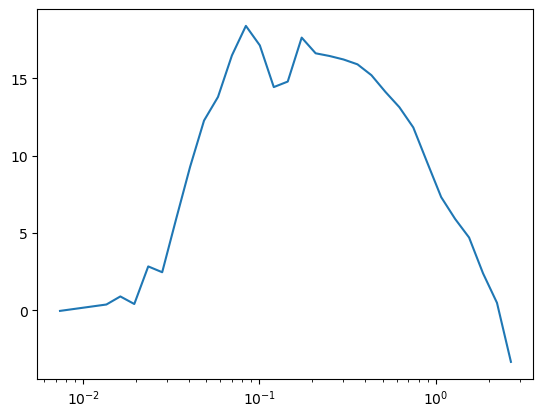

In [6]:
plt.semilogx(r1,sf3/r1)
# plt.semilogx(r11,sf33/r11)

In [ ]:
8*1.